# PC Filter -- Hardware Correctness Validation

Verifies that the FPGA implementation of the PC (Pixel Classification) restoration filter
faithfully reproduces the trained software model, across all uploaded test sequences.

For each sequence, the FPGA's output is compared pixel-by-pixel against a Python "golden"
reference that implements the exact same fixed-point PC filter math (threshold quantization
-> context index -> cluster lookup -> tap dot-product -> shift/clip), on a fixed sample
region. A high exact-match rate means the RTL correctly implements what was trained.

One representative frame is also shown before/after filtering, purely to illustrate what the
filter visibly does to a frame -- no quality metric is attached to that image; this notebook
is a hardware-fidelity check, not a quality/BD-Rate evaluation.

In [1]:
from pynq import Overlay
import numpy as np
import os, glob, time

BASE     = '/home/xilinx/jupyter_notebooks/pc_filter'
DATASETS = '/home/xilinx/jupyter_notebooks/datasets'

ol     = Overlay(f'{BASE}/pc_filter_bd_wrapper.bit')
dma    = ol.axi_dma_0
pc_flt = ol.pc_filter_0

# Fix for PYNQ start() hang -- DMA is already running after overlay load
dma.sendchannel._first_transfer = True
dma.recvchannel._first_transfer = True

In [2]:
data        = np.load(f'{BASE}/pc_qp_group_1.npz')
T_float     = data['T']
LUT         = data['LUT']
cluster_map = data['cluster_map']
LUT_fixed   = np.round(LUT * 8192).astype(np.int32)

T_Q2_14 = np.round(T_float * 16384).astype(int).tolist()
for i, t in enumerate(T_Q2_14):
    pc_flt.write(i * 4, int(t))

print("Thresholds written:", T_Q2_14)

import sys
sys.path.insert(0, BASE)
from pc_golden import PCGolden

g = PCGolden(f'{BASE}/pc_qp_group_1.npz')
print("Golden model loaded — tap symmetry OK")

Thresholds written: [0, 5, 10, 26, 57, 123, 280]
Golden model loaded — tap symmetry OK


In [3]:
# (width, height) per sequence. Landscape sequences are 1920x1080; the three portrait
# ones are 1080x1920. WalkingInStreet's folder name says 1920x1080 but the content is
# actually portrait -- confirmed by the thumbnail sanity check below, so trust that check
# over any folder name.
RESOLUTIONS = {
    'CrowdRun_1920x1080p50':               (1920, 1080),
    'Motorcycle_1920x1080_30fps_8bit':     (1920, 1080),
    'MountainBike_1920x1080_30fps_8bit':   (1920, 1080),
    'OldTownCross_1920x1080p50':           (1920, 1080),
    'PedestrianArea_1920x1080p25':         (1920, 1080),
    'Riverbed_1920x1080p25':               (1920, 1080),
    'RushFieldCuts_1920x1080_2997':        (1920, 1080),
    'TreesAndGrass_1920_1080_30fps_8bit':  (1920, 1080),
    'Vertical_bees_1080x1920_2997':        (1080, 1920),
    'Vertical_Carnaby_1080x1920_5994':     (1080, 1920),
    'WalkingInStreet_1920x1080_30fps':     (1080, 1920),  # misleading name -- actually portrait
    'WorldCup_1920x1080_30p':              (1920, 1080),
    'WorldCup_far_1920x1080_30p':          (1920, 1080),
}

sequences = []
for name in sorted(os.listdir(DATASETS)):
    path = os.path.join(DATASETS, name)
    if not os.path.isdir(path):
        continue
    if 'Copy' in name or name.endswith('.zip'):
        continue
    if not os.path.isdir(os.path.join(path, 'TEST_HR')):
        continue
    sequences.append(name)

print(f"Found {len(sequences)} sequence directories:")
for name in sequences:
    tag = RESOLUTIONS.get(name, 'NO RESOLUTION SET -- will be skipped')
    print(f"  {name:38s} {tag}")

Found 13 sequence directories:
  CrowdRun_1920x1080p50                  (1920, 1080)
  Motorcycle_1920x1080_30fps_8bit        (1920, 1080)
  MountainBike_1920x1080_30fps_8bit      (1920, 1080)
  OldTownCross_1920x1080p50              (1920, 1080)
  PedestrianArea_1920x1080p25            (1920, 1080)
  Riverbed_1920x1080p25                  (1920, 1080)
  RushFieldCuts_1920x1080_2997           (1920, 1080)
  TreesAndGrass_1920_1080_30fps_8bit     (1920, 1080)
  Vertical_Carnaby_1080x1920_5994        (1080, 1920)
  Vertical_bees_1080x1920_2997           (1080, 1920)
  WalkingInStreet_1920x1080_30fps        (1080, 1920)
  WorldCup_1920x1080_30p                 (1920, 1080)
  WorldCup_far_1920x1080_30p             (1920, 1080)


In [4]:
def load_raw_y(path, W, H):
    with open(path, 'rb') as f:
        return np.frombuffer(f.read(W * H), dtype=np.uint8).reshape(H, W).copy()

def run_fpga(img_np, W, H):
    pc_flt.write(0x1C, (int(H) << 16) | int(W))
    input_buf[:] = img_np.flatten().astype(np.uint32)
    dma.recvchannel.transfer(output_buf)
    dma.sendchannel.transfer(input_buf)
    dma.sendchannel.wait()
    dma.recvchannel.wait()
    interior = (output_buf & 0xFF).astype(np.uint8).reshape(H - 6, W - 6)
    result = img_np.copy()
    result[3:H - 3, 3:W - 3] = interior
    return result

def find_representative(seq_dir, rng='RANGE_1', qp=None):
    """Pick one pre-LR file. Default: highest QP in the range (most compressed)."""
    for r in ([rng] + [x for x in ['RANGE_1','RANGE_0','RANGE_2','RANGE_3','RANGE_4'] if x != rng]):
        files = sorted(glob.glob(f'{seq_dir}/TEST_PRELR/{r}/*.yuv'))
        if not files:
            continue
        if qp is not None:
            m = [f for f in files if f'qp{qp}_' in os.path.basename(f)]
            if m:
                return m[0], r
        return files[-1], r      # was files[0] -> qp160; now qp180
    return None, None

In [5]:
from pynq import allocate

# Total pixel count (W*H) is identical across all sequences here (1920*1080 == 1080*1920),
# so one pair of buffers, sized once, covers every sequence regardless of orientation.
N_in  = 1920 * 1080
N_out = (1080 - 6) * (1920 - 6)
input_buf  = allocate(shape=(N_in,),  dtype=np.uint32)
output_buf = allocate(shape=(N_out,), dtype=np.uint32)
print("Buffers allocated")

Buffers allocated


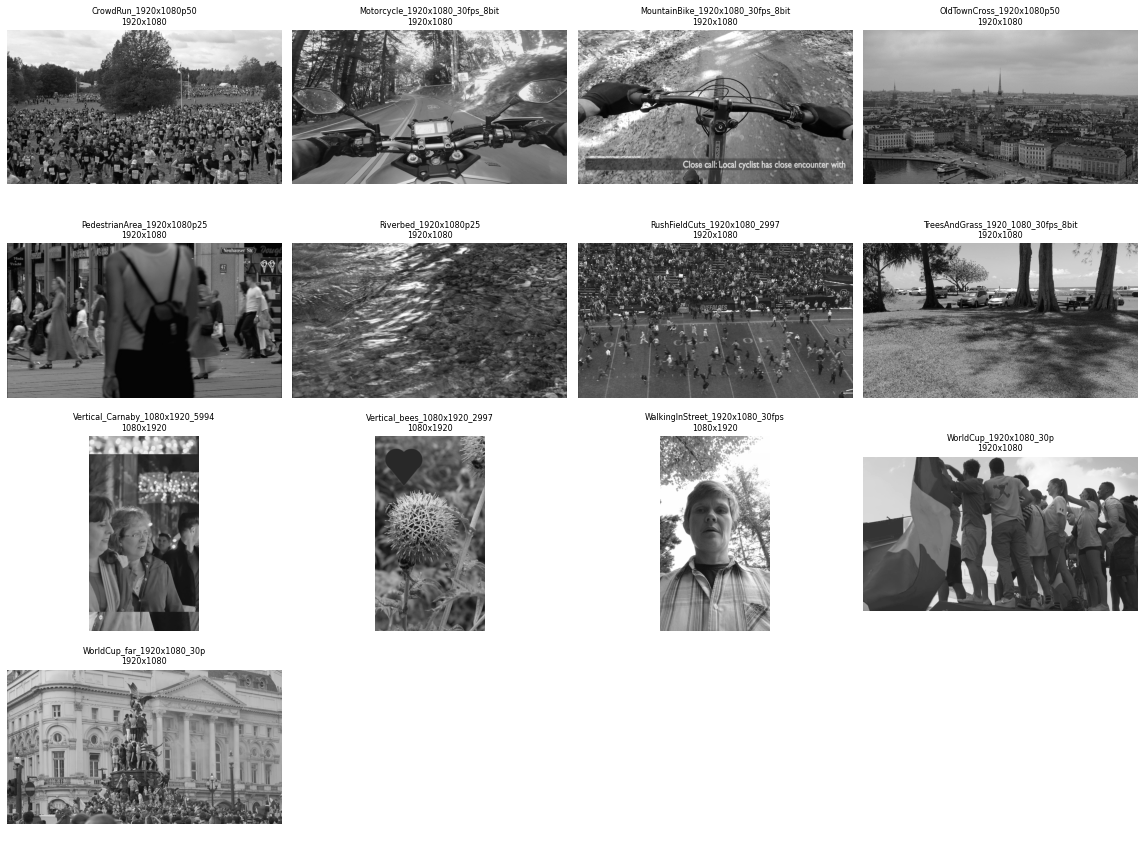

Check each thumbnail: does it look like a normal, unskewed frame?
If one looks stretched/sheared, its (W, H) in RESOLUTIONS is swapped --
fix the tuple in the cell above and re-run before continuing.


In [6]:
import matplotlib.pyplot as plt

cols = 4
rows = (len(sequences) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows))
axes = axes.flatten()

for ax, name in zip(axes, sequences):
    wh = RESOLUTIONS.get(name)
    seq_dir = os.path.join(DATASETS, name)
    hr_files = sorted(glob.glob(f'{seq_dir}/TEST_HR/*.y'))
    if wh is None or not hr_files:
        ax.set_title(f'{name}\n(skipped)', fontsize=8)
        ax.axis('off')
        continue
    W, H = wh
    img = load_raw_y(hr_files[0], W, H)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{name}\n{W}x{H}', fontsize=8)
    ax.axis('off')

for ax in axes[len(sequences):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Check each thumbnail: does it look like a normal, unskewed frame?")
print("If one looks stretched/sheared, its (W, H) in RESOLUTIONS is swapped --")
print("fix the tuple in the cell above and re-run before continuing.")

In [7]:
correctness = []   # (name, range, frame_id, qp, mae, exact_pct)
skipped     = []

for name in sequences:
    if name not in RESOLUTIONS:
        skipped.append((name, 'unknown resolution')); continue
    W, H = RESOLUTIONS[name]
    seq_dir = os.path.join(DATASETS, name)

    prelr_path, rng = find_representative(seq_dir)
    if prelr_path is None:
        skipped.append((name, 'no pre-LR files found')); continue

    fname = os.path.basename(prelr_path)
    parts = fname.replace('_prelr.yuv', '').split('_')
    frame_id, qp = parts[1], parts[2].replace('qp', '')

    prelr    = load_raw_y(prelr_path, W, H)
    filtered = run_fpga(prelr, W, H)
    gold     = g.filter_image(prelr)          # full frame, vectorised

    gi, fi = gold[3:-3, 3:-3], filtered[3:-3, 3:-3]
    mae    = float(np.mean(np.abs(gi.astype(int) - fi.astype(int))))
    exact  = float(np.mean(gi == fi) * 100)

    correctness.append((name, rng, frame_id, qp, mae, exact))
    print(f"{name:38s} {frame_id} qp{qp}  MAE={mae:5.3f}  exact={exact:6.2f}%")

CrowdRun_1920x1080p50                  117 qp180  MAE=0.000  exact=100.00%
Motorcycle_1920x1080_30fps_8bit        117 qp180  MAE=0.000  exact=100.00%
MountainBike_1920x1080_30fps_8bit      117 qp180  MAE=0.000  exact=100.00%
OldTownCross_1920x1080p50              117 qp180  MAE=0.000  exact=100.00%
PedestrianArea_1920x1080p25            117 qp180  MAE=0.000  exact=100.00%
Riverbed_1920x1080p25                  117 qp180  MAE=0.000  exact=100.00%
RushFieldCuts_1920x1080_2997           117 qp180  MAE=0.000  exact=100.00%
TreesAndGrass_1920_1080_30fps_8bit     117 qp180  MAE=0.000  exact=100.00%
Vertical_Carnaby_1080x1920_5994        117 qp180  MAE=0.000  exact=100.00%
Vertical_bees_1080x1920_2997           117 qp180  MAE=0.000  exact=100.00%
WalkingInStreet_1920x1080_30fps        117 qp180  MAE=0.000  exact=100.00%
WorldCup_1920x1080_30p                 117 qp180  MAE=0.000  exact=100.00%
WorldCup_far_1920x1080_30p             117 qp180  MAE=0.000  exact=100.00%


In [8]:
# ── PSNR sweep: 13 sequences x 3 QPs (RANGE_1) ───────────────────────────────
# Paste as a notebook cell. Requires: sequences, RESOLUTIONS, DATASETS,
# load_raw_y, run_fpga, find_representative(seq_dir, rng=, qp=)

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return 10 * np.log10(255 ** 2 / mse) if mse > 0 else float('inf')


RU = 64
psnr_rows = []          # (name, qp, before, after, gain, ru_blanket, ru_oracle, ru_win%)

for name in sequences:
    if name not in RESOLUTIONS:
        continue
    W, H = RESOLUTIONS[name]
    seq_dir = os.path.join(DATASETS, name)

    for qp in ['160', '170', '180']:
        prelr_path, rng = find_representative(seq_dir, qp=qp)
        if prelr_path is None:
            continue

        fname    = os.path.basename(prelr_path)
        frame_id = fname.replace('_prelr.yuv', '').split('_')[1]
        hr_path  = os.path.join(seq_dir, 'TEST_HR', f'frame_{frame_id}.y')
        if not os.path.exists(hr_path):
            continue

        prelr    = load_raw_y(prelr_path, W, H)
        hr       = load_raw_y(hr_path, W, H)
        filtered = run_fpga(prelr, W, H)

        # Frame-level PSNR on the filtered interior only
        pb = psnr(prelr[3:-3, 3:-3],    hr[3:-3, 3:-3])
        pa = psnr(filtered[3:-3, 3:-3], hr[3:-3, 3:-3])

        # Per-restoration-unit gain
        ru_g = []
        for i in range(3, H - 3 - RU, RU):
            for j in range(3, W - 3 - RU, RU):
                p = prelr[i:i+RU, j:j+RU].astype(np.float64)
                f = filtered[i:i+RU, j:j+RU].astype(np.float64)
                t = hr[i:i+RU, j:j+RU].astype(np.float64)
                mp, mf = np.mean((p - t) ** 2), np.mean((f - t) ** 2)
                if mp > 0 and mf > 0:
                    ru_g.append(10 * np.log10(mp / mf))
        ru_g = np.array(ru_g)

        psnr_rows.append((name, qp, pb, pa, pa - pb,
                          ru_g.mean(), np.maximum(ru_g, 0).mean(),
                          100 * (ru_g > 0).mean()))

        print(f"{name:38s} qp{qp}  before={pb:6.3f}  after={pa:6.3f}  "
              f"gain={pa-pb:+.4f} dB  RU_win={100*(ru_g>0).mean():5.1f}%")

print(f"\nDone — {len(psnr_rows)} (sequence, QP) pairs.")

CrowdRun_1920x1080p50                  qp160  before=29.216  after=29.309  gain=+0.0929 dB  RU_win= 81.2%
CrowdRun_1920x1080p50                  qp170  before=27.766  after=27.838  gain=+0.0712 dB  RU_win= 80.8%
CrowdRun_1920x1080p50                  qp180  before=26.393  after=26.447  gain=+0.0544 dB  RU_win= 77.2%
Motorcycle_1920x1080_30fps_8bit        qp160  before=30.218  after=30.306  gain=+0.0881 dB  RU_win= 68.8%
Motorcycle_1920x1080_30fps_8bit        qp170  before=28.456  after=28.547  gain=+0.0920 dB  RU_win= 73.5%
Motorcycle_1920x1080_30fps_8bit        qp180  before=26.858  after=26.926  gain=+0.0676 dB  RU_win= 70.9%
MountainBike_1920x1080_30fps_8bit      qp160  before=31.439  after=31.464  gain=+0.0252 dB  RU_win= 53.7%
MountainBike_1920x1080_30fps_8bit      qp170  before=29.875  after=29.881  gain=+0.0055 dB  RU_win= 48.5%
MountainBike_1920x1080_30fps_8bit      qp180  before=28.429  after=28.442  gain=+0.0132 dB  RU_win= 52.6%
OldTownCross_1920x1080p50              qp160  

GAIN vs QP  (higher QP = stronger compression = more artefacts to remove)
  QP  Seqs    Before     After       Gain   RU oracle   RU win%
------------------------------------------------------------------------
 160    13    32.828    32.847    +0.0188     +0.0370     53.8
 170    13    31.333    31.351    +0.0181     +0.0298     55.9
 180    13    29.897    29.910    +0.0128     +0.0231     55.6
------------------------------------------------------------------------
 ALL    39    31.353    31.369    +0.0166     +0.0300     55.1

PER-SEQUENCE GAIN (dB)
Sequence                                    qp160      qp170      qp180       mean
--------------------------------------------------------------------------------------
CrowdRun_1920x1080p50                    +0.0929   +0.0712   +0.0544   +0.0728
Motorcycle_1920x1080_30fps_8bit          +0.0881   +0.0920   +0.0676   +0.0826
MountainBike_1920x1080_30fps_8bit        +0.0252   +0.0055   +0.0132   +0.0147
OldTownCross_1920x1080p50        

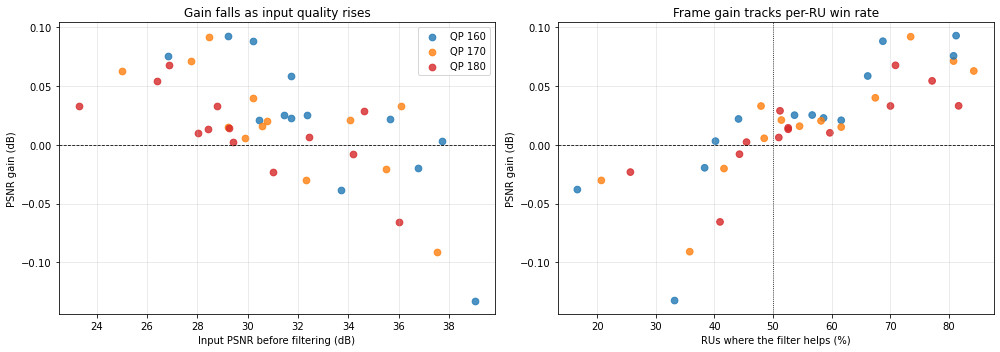

In [9]:
# ── Summary tables (run after the PSNR sweep cell) ───────────────────────────

# 1. Gain vs QP — the headline trend
print("=" * 72)
print("GAIN vs QP  (higher QP = stronger compression = more artefacts to remove)")
print("=" * 72)
print(f"{'QP':>4s} {'Seqs':>5s} {'Before':>9s} {'After':>9s} {'Gain':>10s} "
      f"{'RU oracle':>11s} {'RU win%':>9s}")
print("-" * 72)
for qp in ['160', '170', '180']:
    rows = [r for r in psnr_rows if r[1] == qp]
    if not rows:
        continue
    print(f"{qp:>4s} {len(rows):5d} "
          f"{np.mean([r[2] for r in rows]):9.3f} "
          f"{np.mean([r[3] for r in rows]):9.3f} "
          f"{np.mean([r[4] for r in rows]):+10.4f} "
          f"{np.mean([r[6] for r in rows]):+11.4f} "
          f"{np.mean([r[7] for r in rows]):8.1f}")
print("-" * 72)
print(f"{'ALL':>4s} {len(psnr_rows):5d} "
      f"{np.mean([r[2] for r in psnr_rows]):9.3f} "
      f"{np.mean([r[3] for r in psnr_rows]):9.3f} "
      f"{np.mean([r[4] for r in psnr_rows]):+10.4f} "
      f"{np.mean([r[6] for r in psnr_rows]):+11.4f} "
      f"{np.mean([r[7] for r in psnr_rows]):8.1f}")

# 2. Per-sequence, gain at each QP side by side
print("\n" + "=" * 86)
print("PER-SEQUENCE GAIN (dB)")
print("=" * 86)
print(f"{'Sequence':38s} {'qp160':>10s} {'qp170':>10s} {'qp180':>10s} {'mean':>10s}")
print("-" * 86)
for name in sequences:
    rows = {r[1]: r[4] for r in psnr_rows if r[0] == name}
    if not rows:
        continue
    vals = [rows.get(q) for q in ['160', '170', '180']]
    cells = ''.join(f"{v:+10.4f}" if v is not None else f"{'--':>10s}" for v in vals)
    present = [v for v in vals if v is not None]
    print(f"{name:38s}{cells}{np.mean(present):+10.4f}")

# 3. Does gain scale with compression? Correlation of gain vs input PSNR
before = np.array([r[2] for r in psnr_rows])
gain   = np.array([r[4] for r in psnr_rows])
win    = np.array([r[7] for r in psnr_rows])

print("\n" + "=" * 72)
print("CORRELATIONS")
print("=" * 72)
print(f"gain vs input PSNR : r = {np.corrcoef(before, gain)[0,1]:+.3f}   "
      f"(negative expected: less damage -> less to gain)")
print(f"gain vs RU win%    : r = {np.corrcoef(win, gain)[0,1]:+.3f}   "
      f"(positive expected)")
print(f"Pairs with gain > 0: {(gain > 0).sum()} / {len(gain)}")

# 4. Scatter — gain against input PSNR, coloured by QP
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colours = {'160': 'tab:blue', '170': 'tab:orange', '180': 'tab:red'}
for qp in ['160', '170', '180']:
    rows = [r for r in psnr_rows if r[1] == qp]
    if rows:
        axes[0].scatter([r[2] for r in rows], [r[4] for r in rows],
                        c=colours[qp], label=f'QP {qp}', s=45, alpha=0.8)
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_xlabel('Input PSNR before filtering (dB)')
axes[0].set_ylabel('PSNR gain (dB)')
axes[0].set_title('Gain falls as input quality rises')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(win, gain, c=[colours[r[1]] for r in psnr_rows], s=45, alpha=0.8)
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].axvline(50, color='k', lw=0.8, ls=':')
axes[1].set_xlabel('RUs where the filter helps (%)')
axes[1].set_ylabel('PSNR gain (dB)')
axes[1].set_title('Frame gain tracks per-RU win rate')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
exacts = [c[5] for c in correctness]
maes   = [c[4] for c in correctness]

print("=" * 60)
print(f"Sequences checked   : {len(correctness)} / {len(sequences)}")
print(f"Mean exact-match    : {np.mean(exacts):.1f}%")
print(f"Worst exact-match   : {min(exacts):.1f}% ({correctness[int(np.argmin(exacts))][0]})")
print(f"Mean MAE            : {np.mean(maes):.3f}")
print("=" * 60)

print(f"\n{'Sequence':38s} {'Frame':>10s} {'QP':>4s} {'Exact%':>8s} {'MAE':>6s}")
for name, rng, frame_id, qp, mae, exact in correctness:
    print(f"{name:38s} {frame_id:>10s} {qp:>4s} {exact:8.1f} {mae:6.2f}")

Sequences checked   : 13 / 13
Mean exact-match    : 100.0%
Worst exact-match   : 100.0% (CrowdRun_1920x1080p50)
Mean MAE            : 0.000

Sequence                                    Frame   QP   Exact%    MAE
CrowdRun_1920x1080p50                         117  180    100.0   0.00
Motorcycle_1920x1080_30fps_8bit               117  180    100.0   0.00
MountainBike_1920x1080_30fps_8bit             117  180    100.0   0.00
OldTownCross_1920x1080p50                     117  180    100.0   0.00
PedestrianArea_1920x1080p25                   117  180    100.0   0.00
Riverbed_1920x1080p25                         117  180    100.0   0.00
RushFieldCuts_1920x1080_2997                  117  180    100.0   0.00
TreesAndGrass_1920_1080_30fps_8bit            117  180    100.0   0.00
Vertical_Carnaby_1080x1920_5994               117  180    100.0   0.00
Vertical_bees_1080x1920_2997                  117  180    100.0   0.00
WalkingInStreet_1920x1080_30fps               117  180    100.0   0.00
WorldCu

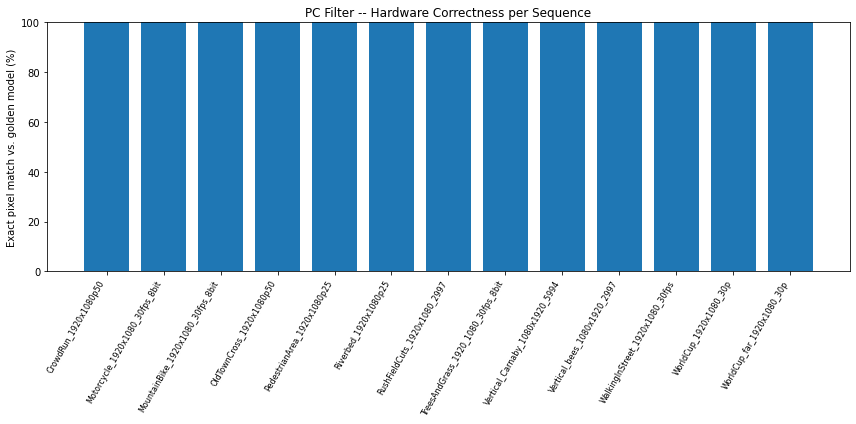

In [11]:
import matplotlib.pyplot as plt

names  = [c[0] for c in correctness]
exacts = [c[5] for c in correctness]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(names)), exacts, color='tab:blue')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=60, ha='right', fontsize=8)
ax.set_ylim(0, 100)
ax.set_ylabel('Exact pixel match vs. golden model (%)')
ax.set_title('PC Filter -- Hardware Correctness per Sequence')
plt.tight_layout()
plt.show()

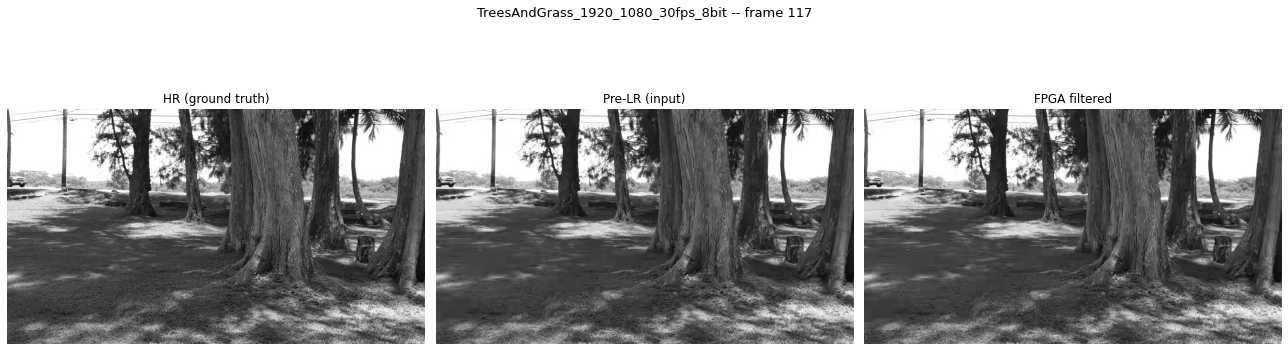

In [12]:
# Illustrative only: show one frame before/after filtering. No quality metric attached --
# this is just to show what the filter visibly does, not to claim a gain.
show_name = 'TreesAndGrass_1920_1080_30fps_8bit' if 'TreesAndGrass_1920_1080_30fps_8bit' in sequences else sequences[0]
W, H = RESOLUTIONS[show_name]
seq_dir = os.path.join(DATASETS, show_name)

prelr_path, rng = find_representative(seq_dir)
fname = os.path.basename(prelr_path)
frame_id = fname.replace('_prelr.yuv', '').split('_')[1]
hr_path = os.path.join(seq_dir, 'TEST_HR', f'frame_{frame_id}.y')

prelr    = load_raw_y(prelr_path, W, H)
hr       = load_raw_y(hr_path, W, H)
filtered = run_fpga(prelr, W, H)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(hr,       cmap='gray', vmin=0, vmax=255); axes[0].set_title('HR (ground truth)'); axes[0].axis('off')
axes[1].imshow(prelr,    cmap='gray', vmin=0, vmax=255); axes[1].set_title('Pre-LR (input)');     axes[1].axis('off')
axes[2].imshow(filtered, cmap='gray', vmin=0, vmax=255); axes[2].set_title('FPGA filtered');      axes[2].axis('off')
plt.suptitle(f'{show_name} -- frame {frame_id}', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
input_buf.freebuffer()
output_buf.freebuffer()
print("Done.")

Done.
